In [1]:
# %pip install neurokit2

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv
import os, sys
import matplotlib.pyplot as plt
import neurokit2 as nk


# Matplotlib defaults for clean plots
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# ECG Signal Processing for HRV — Companion Notebook

This notebook walks through the signal processing steps used in the article "[*From Raw ECG to HRV — How Heartbeats Become Insight*](https://blog.paulmrichardson.com/ecg-signal-processing-hrv)" It serves as a transparent, reproducible reference for readers who want to see how the signal processing streps for my ECG workflow is implemented in code.

Rather than relying on a single library call to complete this task (signal to HRV Indices in three steps), I take a step-by-step approach that mirrors my understanding of the logic for classical ECG signal processing — from filtering and smoothing to peak detection and R-R interval validation. Each cell combines code, visualization, and explanation so you can trace how raw electrical activity becomes clean, interpretable data ready for HRV analysis.

In this notebook we will cover:

- Loading and visualizing ECG data
- Filtering and smoothing the signal
- Detecting R-peaks (manual + NeuroKit2)
- Computing and validating R-R intervals

Each section includes both code and plots so you can see how every step transforms the signal. The goal is to make the process transparent — from preprocessing to validation — so you can trust that the HRV metrics reflect physiology, not noise.

My goal for writing my article and preparing this notebook was to statisfy my curiosity. I do hope that it might be benefical to others and accurately helps you see how your wearable device turns heartbeats into insight. 

Please note I am not an expert, just a very curious IT guys with a degree in data science. This is part 1 of a two (or three part series). 

# About the Data
This notebook is using the ECG data from mit-bih database from physionet in plain text format. I am using the data hosted on Kaggle.

In ECG data analysis, signals may come from either chest (V1–V6) or limb leads such as MLII (Modified Lead II). The V leads record activity from different points across the chest, while MLII—a common configuration used in wearables and research—captures the heart’s electrical activity from the right arm to the left leg vector, producing a strong, upright R-wave. For preprocessing and HRV analysis, any lead with clear, distinct R-peaks and minimal noise can be used, whether it’s a chest or limb lead.

For HRV and R-peak analysis, MLII is generally preferred because it provides large, stable R-waves with minimal noise, making it ideal for accurate interval detection (Task Force, 1996, Circulation, 93 (5): 1043-1065).

The MIT-BIH Arrhythmia Database consists of 48 half-hour, two-channel ECG recordings from 47 subjects, originally collected at Boston’s Beth Israel Hospital. Each signal was digitized at 360 Hz with 11-bit resolution over a 10 mV range, providing high-quality data suitable for R-peak detection and HRV analysis. The data provided in the MIT-BIH Arrhythmia Database has several ECG readings that vary between chest leads but has a consist use of the MLII lead.

For this analysis and guidance from what appears to be industry practice we will use the MLII lead for this effort. We will also only be analyzing a single file:

For processing - 112.csv
For validation - 112annotations.txt

## Exploratory Analysis

The file contains 650k records which represents about 30 hours worth of data. We will preprocess all of the data and for our analysis / HRV metrics we will use a 5 min segment. For consistency across HRV research, five-minute ECG recordings under resting, stationary conditions are used for short-term HRV analysis, unless the study design requires otherwise[2]. For the following steps we will use small segments of 10 to 30 secs to keep the plots focused as they will be more illustrative. 

In [3]:
# Variables
CSV_PATH = "/kaggle/input/mitbih-database/112.csv"  # file path
FS = 360   # Frequency sampling (FS) Rate 360 according to website and data description
start_s, duration_s = 0, 5  # change to view time segments
i0, i1 = int(start_s * FS), int((start_s + duration_s) * FS)

# Read CSV file
df = pd.read_csv(CSV_PATH )
ecg_raw = df["'MLII'"]

### Neurokit2 has a pipeline feature for ECG that will assess and produce a lot of valuable information very quickly. I will show that quickly and move to recreating these step by step. 

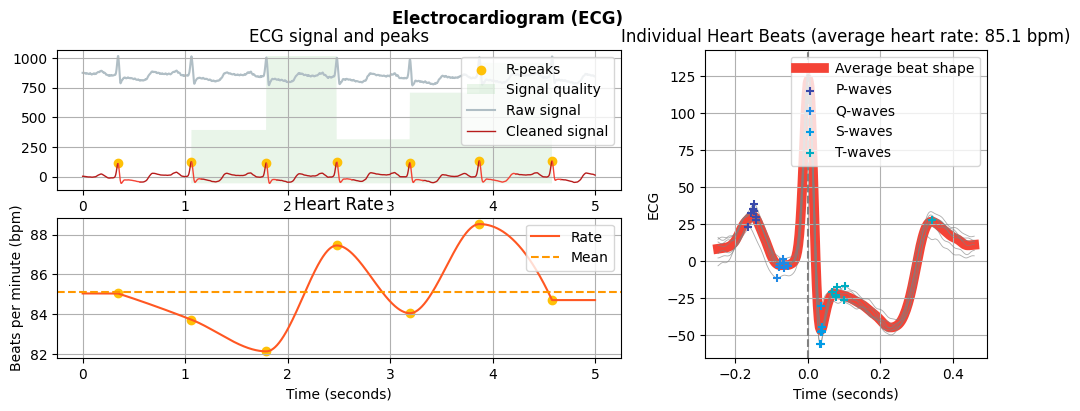

In [4]:
#seconds segment of the raw ecg data
signals, info = nk.ecg_process(ecg_raw[i0:i1], sampling_rate = FS)
nk.ecg_plot(signals, info)

# Cleaning the Signal

Before analysis, the ECG must be cleaned. 

Before filtering, detrending stabilizes the ECG baseline by removing slow voltage drift. This prevents the signal from being biased or pulled away from its true center, allowing subsequent filters to focus on the physiological components of interest. 

A bandpass filter (typically 0.5–40 Hz for HRV) removes slow baseline drift and high-frequency noise. A bandpass filter is the combination of both a high and low pass filter.

By default neurokit2 will apply a powerline filter to remove the 50 Hz band from the noise. Generally in north america the electrical system hovers around 60 Hz while the rest of world is at 50 Hz. I will keep the defaults as this will be true in most of the processing work for neurokit2. 

The result a stable waveform where heartbeats are clear and consistent. To illustrate this I have provided a simulated drift of a clean signal to to illustrate the effect and then applied this concept to our data.  

This keeps only the frequencies where true cardiac activity occurs — the sharp QRS complexes that define each beat. In the next steps, we’ll walk through how to clean and prepare the ECG signal so it accurately reflects true physiological changes rather than artifacts.

## The QRS Complex & HRV
In an ECG, each heartbeat produces a waveform made up of the P wave, QRS complex, and T wave.
Among these, the QRS complex is the most pronounced — a rapid burst of electrical activity that reflects ventricular depolarization, when the heart’s main pumping chambers contract.

Within this complex, the R-peak stands out as the tallest and most distinct point. Because every heartbeat generates one R-peak, we can use it as a precise marker of each cardiac cycle.

By measuring the time between consecutive R-peaks — known as the R-R interval — we capture the instantaneous rhythm of the heart. Tracking how these intervals expand and contract over time reveals the heart’s natural variability, or Heart Rate Variability (HRV) — a key indicator of autonomic balance, recovery, and stress.

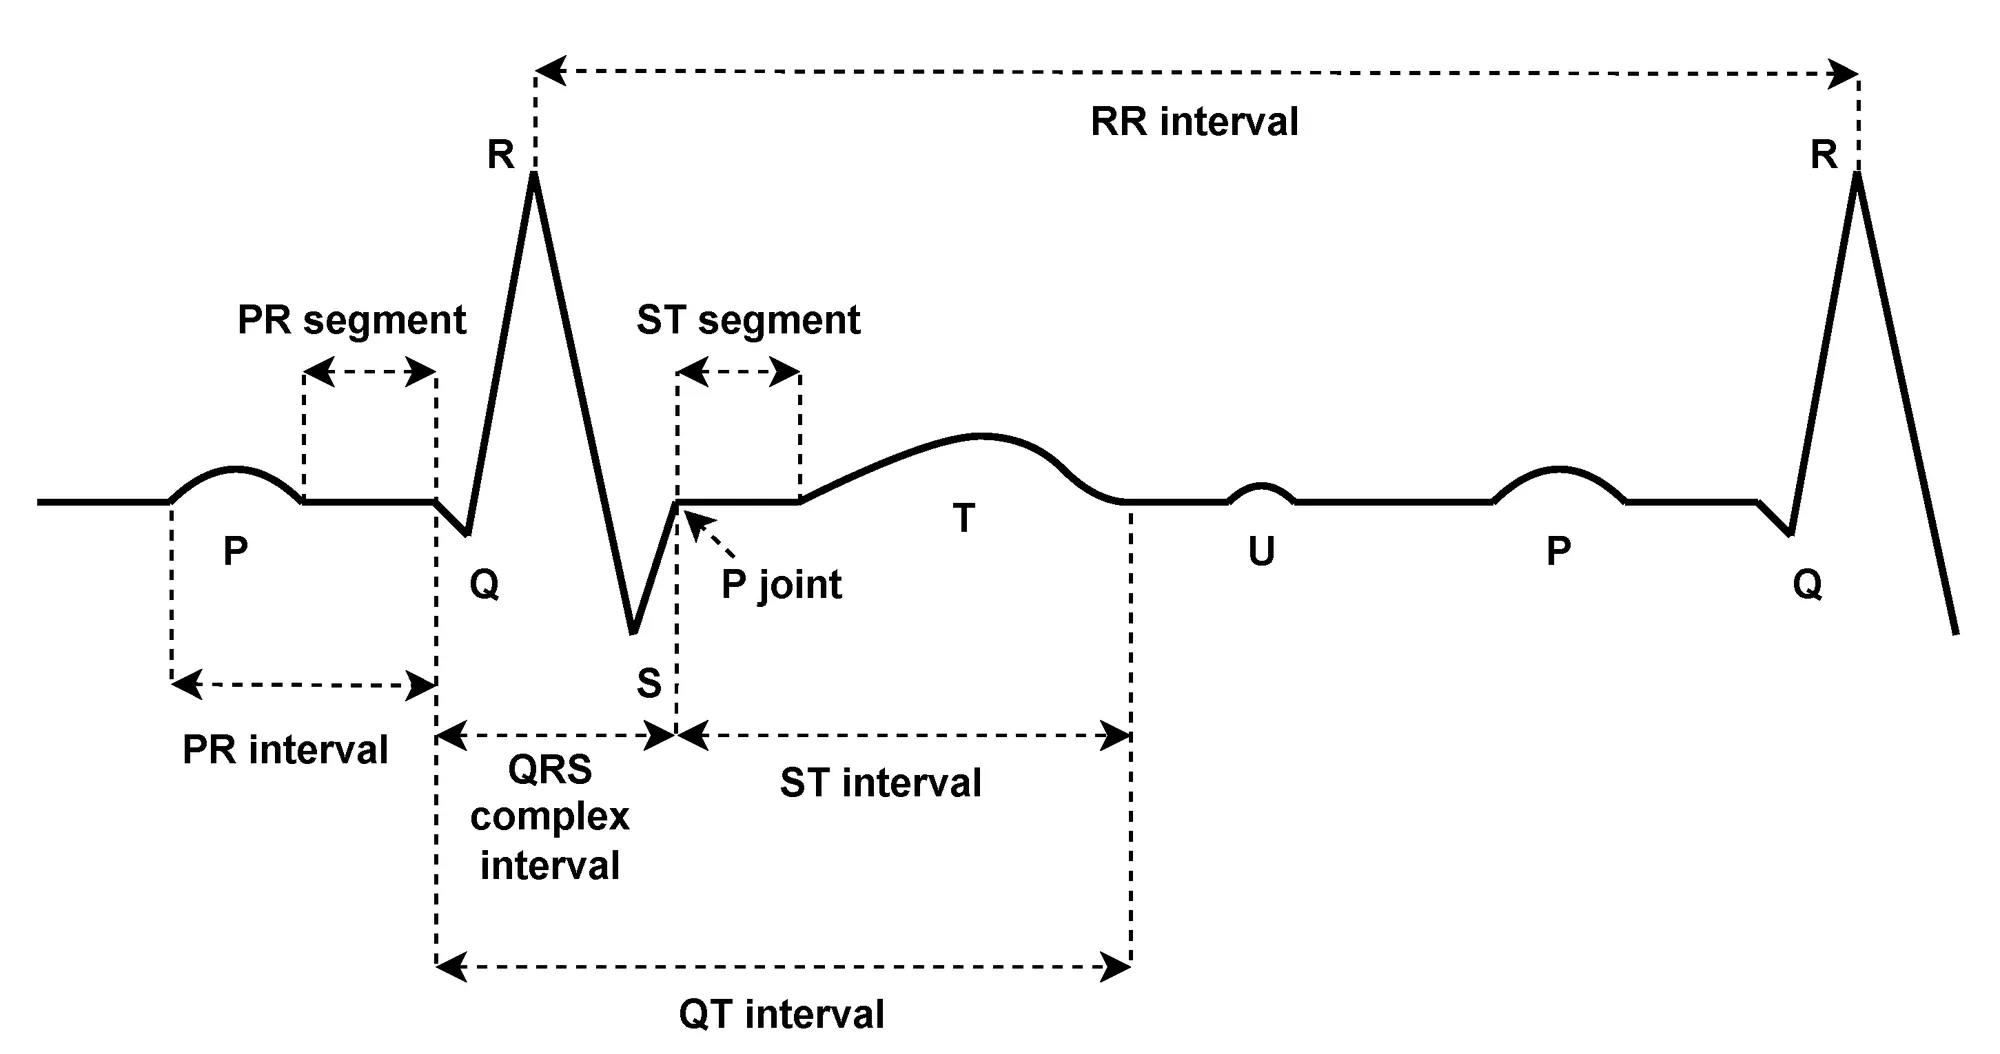
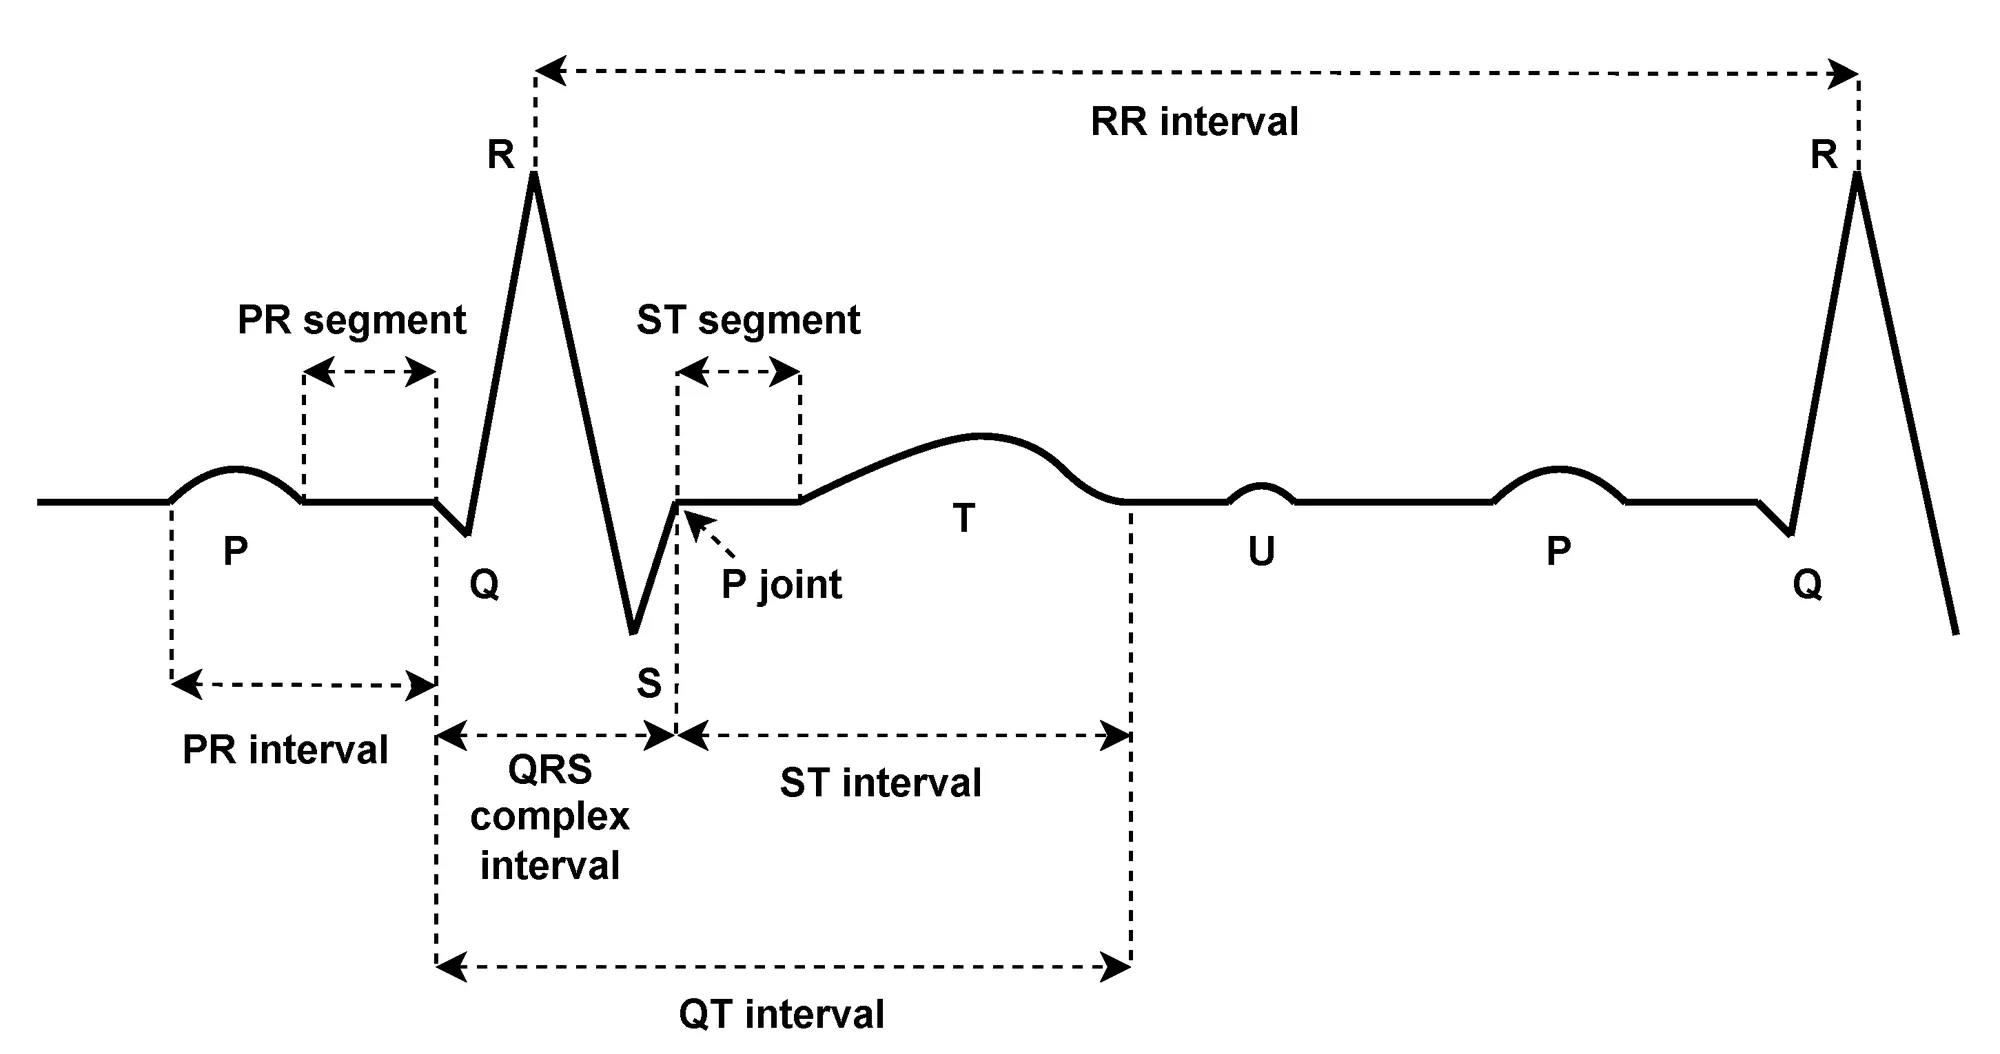

## Raw ECG Data: Our Starting Point

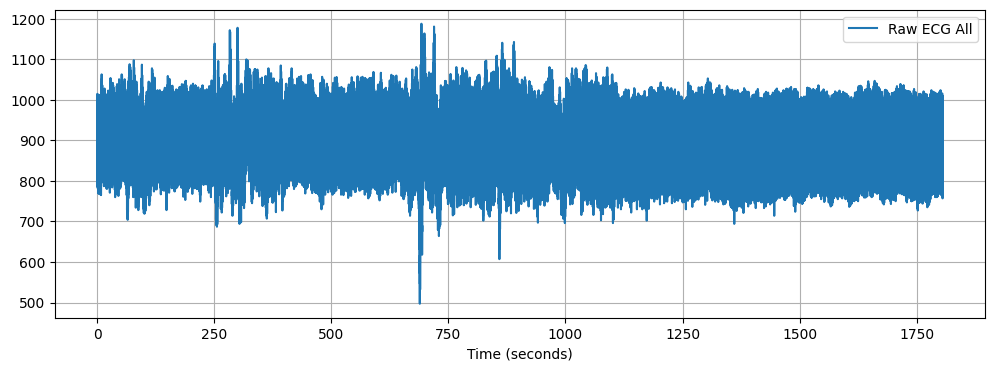

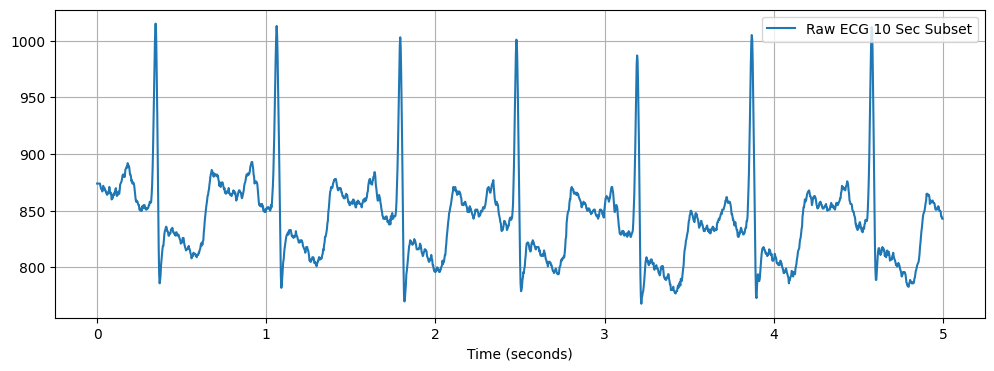

In [5]:
# Raw ECG Data 
nk.signal_plot([ecg_raw],sampling_rate=360, labels=['Raw ECG All'])

# Raw ECG Data 
nk.signal_plot([ecg_raw[i0:i1]],sampling_rate=360, labels=['Raw ECG 10 Sec Subset'])

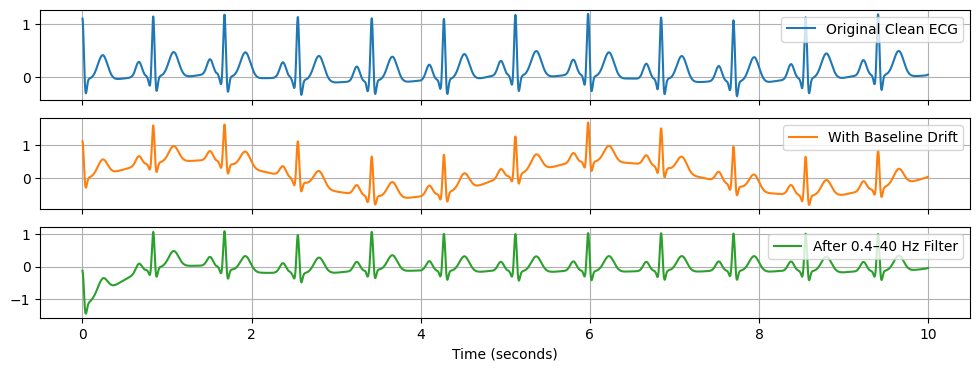

In [6]:
#This is for illustration purposes of Bandpass filtering and illustrate the concept of drift

# Generate or load a clean ECG segment
fs = 360
ecg_clean_true = nk.ecg_simulate(duration=10, sampling_rate=fs)

# Create synthetic baseline drift (a slow sine wave, 0.2 Hz)
t = np.linspace(0, len(ecg_clean_true)/fs, len(ecg_clean_true))
drift = 0.5 * np.sin(2 * np.pi * 0.2 * t)    # amplitude 0.5 mV, slow cycle

# Add drift to the clean ECG
ecg_drifted = ecg_clean_true + drift

# Apply bandpass filtering (remove < 0.4 Hz drift)
ecg_corrected = nk.signal_filter(
    ecg_drifted,
    sampling_rate=fs,
    lowcut=0.4,      # removes baseline drift
    highcut=40,      # keeps only physiological band
    powerline=50,    # this is default but adding for visibility
    method="butterworth",
    order=5
)

nk.signal_plot(
    [ecg_clean_true, ecg_drifted, ecg_corrected],
    sampling_rate=fs,
    labels=["Original Clean ECG", "With Baseline Drift", "After 0.4–40 Hz Filter"],    
    standardize=False,
    subplots=True,    
)

## Detrending & Filtering

ecg_detrend()
- the default method is "tarvainen2002"
- mostly used in HRV analyses as a lowpass filter to remove complex trends
- default regularization is 500 for this method (we will stick with that)

signal_filter()
-  lowcut default is None - for HRV we want 0.4 - This removes low frequency noise
- highcut default is None - for HRV we want 40 - This removes high frequency noise
- method ="butterworth" is default - recommended for general purpose filtering
- order = 2 is default but for HRV we want 5 - Steeper roll off common for HRV
- powerline default is 50 - will leave this already covered in notebook

According to the documentaiton:

ecg_detrend()
- the default method is "tarvainen2002"
- mostly used in HRV analyses as a lowpass filter to remove complex trends
- default regularization is 500 for this method (we will stick with that)

signal_filter()
-  lowcut default is None - for HRV we want 0.4 - This removes low frequency noise
- highcut default is None - for HRV we want 40 - This removes high frequency noise
- method ="butterworth" is default - recommended for general purpose filtering
- order = 2 is default but for HRV we want 5 - Steeper roll off common for HRV
- powerline default is 50 - will leave this already covered in notebook

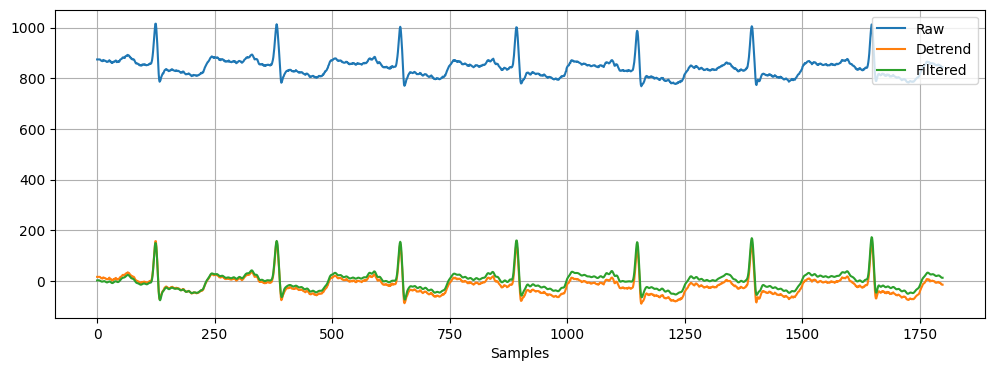

In [7]:
# Detrending to remove drift 
ecg_detrend = nk.signal_detrend(ecg_raw)

#Bandpass Filtering 
ecg_filtered = nk.signal_filter(ecg_detrend, 
                               sampling_rate=360,
                               lowcut=0.4, # Removes low frequency
                               highcut=40, # removes high frequency noise
                               method="butterworth", #recommended for general purpose filtering
                               order=5 #Steeper roll off common for HRV
                               )

nk.signal_plot(
    [ecg_raw[i0:i1], ecg_detrend[i0:i1], ecg_filtered[i0:i1]], 
    subplots = False, 
    standardize=False,
    labels=["Raw", "Detrend", "Filtered",])

**Raw**: The raw ECG shows a large baseline offset and noticeable drift, which inflate the apparent amplitude. These shifts come from sensor bias, skin–electrode impedance, and slow movement artifacts rather than true cardiac activity.

**Detrended**: Detrending removes this slow wander and recenters the signal around zero, revealing the genuine voltage fluctuations produced by the heart. The amplitude decreases sharply here because the non-physiological baseline has been stripped away.

**Filtered**: The bandpass filter (typically 0.5–45 Hz) further refines the waveform by removing both low-frequency drift and high-frequency noise. The signal’s shape becomes crisp and stable, with R-peaks clearly standing out.

**Result**: The final ECG now reflects authentic cardiac activity—lower in amplitude but clean, consistent, and physiologically accurate—providing a reliable foundation for R-peak detection and HRV analysis.

## Signal Quality

Neurokit2 multiple ways to validate signal quality. One using a function that programmically uses a method outlined in a paper proposed by Zhao et al. (2018). This can be done on the raw data but is recommened to be evaluated on each segment after light processing. Our signal is **Barely acceptable** which will have to be sufficient.

The three possible outcomes are
1. Unacceptable
2. Barely Acceptable 
3. Excellent

In [8]:
# cleaned data
ecg_cleaned = ecg_filtered

# Check ecg signal quality of cleaned data
print(nk.ecg_quality(ecg_cleaned,               
               sampling_rate=360,
               method="zhao2018",
               approach="fuzzy"))

Barely acceptable


### Neurokit2: ecg_clean() vs signal_filter() and signal_detrend()
Neurokit offers the ecg_clean() function which handles all of the above processing. However it makes some different assumptions and tradeoffs. 

ecg_clean() is designed for general purpose ECG cleaning and tries to maintain as much of the signal as possible. For specific HRV work you may choose to process the data as we approached it for a little more control. 

ecg_clean() does not apply a high cut. It only detrends and standardizes. It maintains a default powerline filter of 50 Hz. It does supply several methods for the cleaning approach. A popular approach for truly isolating the QRS complex is captured in the "pantompkins1985" method which applies a bandpass filter or 5 to 15 Hz. This is however too narrow for all of the HRV metrics. 

Depending on the quality of the data and ultimately what your trying to achieve their are plenty of options. For our objectives we will demonstrate the differences but stick to our manually cleaned data with focus on HRV. However, many of the nuerokit defaults will not have used the high band filter. 

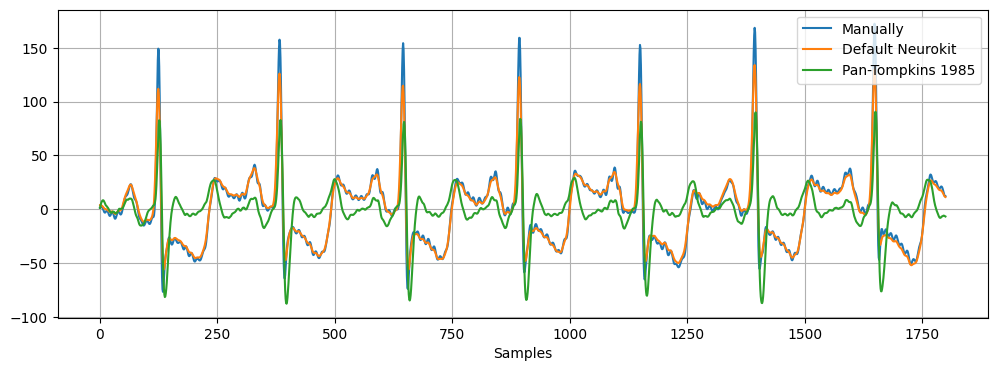

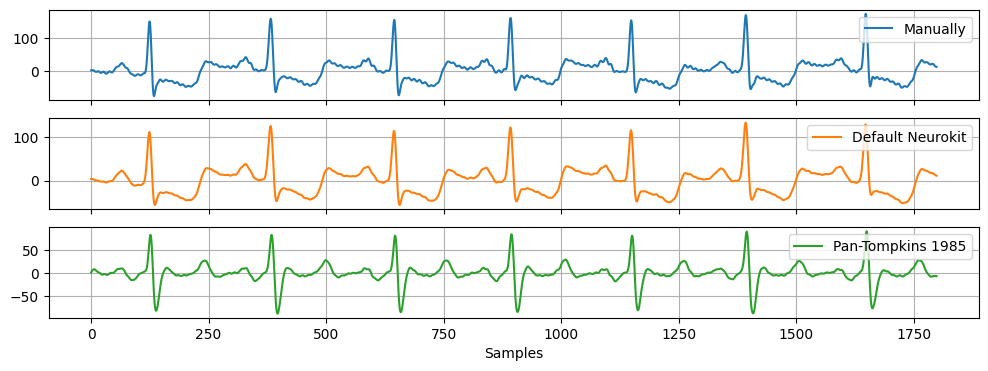

In [9]:
# Our manually cleaned data
ecg_manual_clean = ecg_cleaned

# neurokit clean with default method
ecg_neuro_clean = nk.ecg_clean(ecg_raw, sampling_rate=360, method='neurokit')

# neurokit clean with pantompkins1985 approach
ecg_pantomp_clean = nk.ecg_clean(ecg_raw, sampling_rate=360, method='pantompkins1985')


nk.signal_plot(
    [ecg_manual_clean[i0:i1], ecg_neuro_clean[i0:i1], ecg_pantomp_clean[i0:i1]], 
    subplots = False,
    standardize= False,
    labels=["Manually", "Default Neurokit", "Pan-Tompkins 1985"])

nk.signal_plot(
    [ecg_manual_clean[i0:i1], ecg_neuro_clean[i0:i1], ecg_pantomp_clean[i0:i1]], 
    subplots = True,
    standardize= False,
    labels=["Manually", "Default Neurokit", "Pan-Tompkins 1985"])

# Finding the Peaks

For learning purposes we will walk through each of steps in a rudamentary fashion. Our approach will try to isolate the QRS segment for peak detection. This will very roughly approximate how neurokit uses ecg_peaks() but the function absolutely more robust. 

## Differentiation

**Signal Differentiation:** This step emphasizes how quickly the ECG waveform changes — highlighting sharp transitions or steep slopes in the signal. In the context of ECG, these rapid changes typically occur around the QRS complex, where the heart’s electrical activity spikes as the ventricles contract. By differentiating the signal, we make those steep regions more pronounced, helping to isolate the R-peaks from the slower baseline variations and other low-frequency components.

## Squaring

**Squaring the Differtiated Signal:** This step removes any ambiguity between positive and negative slopes, amplifies large changes, and suppresses smaller fluctuations — turning each strong heartbeat into a tall, clear spike.

## Smoothing (Moving-Window Integration)

**Smoothing (Moving-Window Integration):** This step averages the signal over roughly one-tenth of a second so that each heartbeat appears as a rounded hill instead of a narrow spike. This makes things easier to see, and visualize the QRS region.

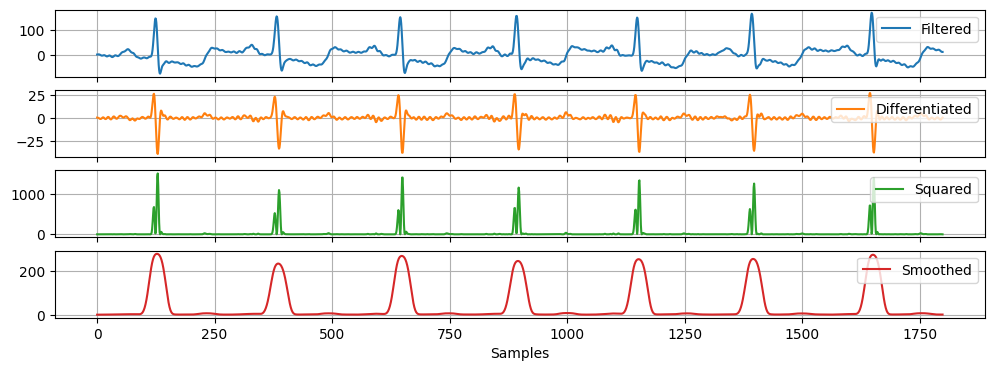

In [10]:
# Differentiated
ecg_diff = np.gradient(ecg_cleaned)

# Squared
ecg_squared = ecg_diff ** 2

# Smoothing (Moving-Window Integration)
window_size = int(0.1* 360)  # 100 ms window for 360 Hz sampling rate
ecg_smoothed = nk.signal_smooth(ecg_squared, method="convolution", size=window_size)

nk.signal_plot([ecg_cleaned[i0:i1], ecg_diff[i0:i1], ecg_squared[i0:i1], ecg_smoothed[i0:i1]], 
               subplots = True,
               labels=["Filtered", "Differentiated", "Squared", "Smoothed"])

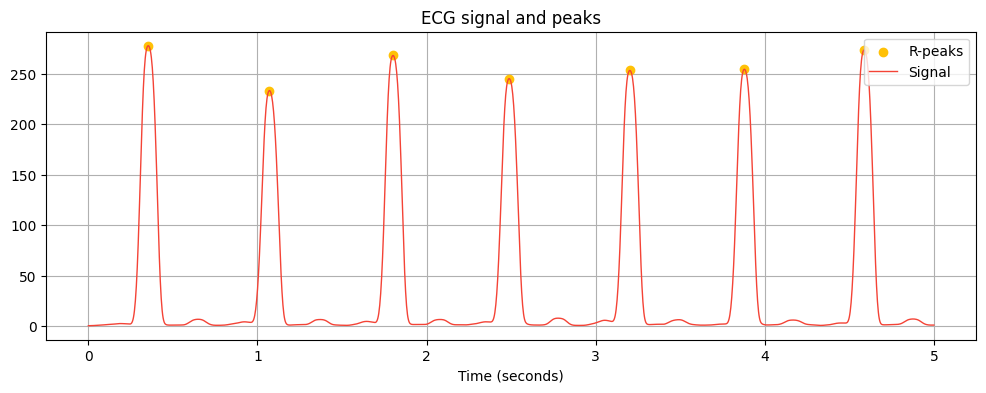

In [11]:
# Built in function from ecg_peaks makes visualization pretty easy. 
signals, info = nk.ecg_peaks(ecg_smoothed[i0:i1], 
                             sampling_rate=360,
                             method="neurokit",                              
                             correct_artifacts=False,
                             show=True)

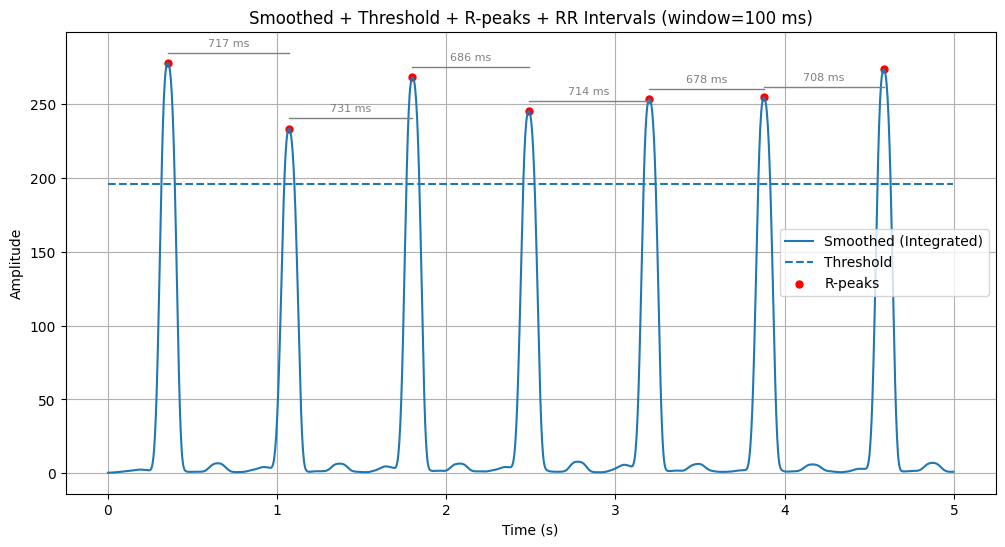

In [12]:
# Visual with the NN Interval timings between peaks
thresh_k = 2.5
sampling_rate = 360
ecg_smooth = ecg_smoothed[i0:i1]

# --- Detect R-peaks
peaks, info = nk.ecg_peaks(ecg_smooth, sampling_rate=sampling_rate)
rpeaks = np.where(peaks["ECG_R_Peaks"] == 1)[0]


# --- Compute RR intervals (in seconds)
rr_intervals = np.diff(rpeaks) / sampling_rate
rr_times = rpeaks[:-1] / sampling_rate

thr = np.median(ecg_smooth) + thresh_k * np.std(ecg_smooth)

# --- Plot
t = np.arange(len(ecg_smooth)) / sampling_rate
plt.figure(figsize=(12, 6))
plt.plot(t, ecg_smooth, label="Smoothed (Integrated)")
plt.hlines(thr, t[0], t[-1], linestyles="dashed", label="Threshold")

# Plot R-peaks
plt.scatter(rpeaks / sampling_rate, ecg_smooth[rpeaks], color="red", s=25, label="R-peaks")

# Add RR interval annotations
for i in range(len(rr_intervals)):
    x1, x2 = rr_times[i], rr_times[i] + rr_intervals[i]
    y = ecg_smooth[rpeaks[i]] + 7  # offset above peak
    plt.plot([x1, x2], [y, y], color="gray", linewidth=1)
    plt.text((x1 + x2) / 2, y + 10, f"{rr_intervals[i]*1000:.0f} ms",
             ha="center", va="top", fontsize=8, color="gray")

plt.title(f"Smoothed + Threshold + R-peaks + RR Intervals (window=100 ms)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(loc="center right")
#plt.tight_layout()
plt.show()


# Validate Peaks 

Validating the peaks derived from the raw ecg data against the annotation files. 

The following validation results confirm that the detected R-peaks and derived R–R intervals are in excellent agreement with the reference annotations.

The Mean Absolute Error (0.57 ms) and Root Mean Squared Error (1.30 ms) indicate sub-millisecond precision, while the Relative Mean Absolute Error (0.08%) shows that detection errors are negligible compared to the average heartbeat duration.

The Reference Mean R–R Interval (711.1 ms) matches the detected mean exactly, and the Reference RMSSD (20.1 ms) is nearly identical to the detected value (20.0 ms), confirming that short-term variability has been preserved.

With this level of accuracy, our preprocessing and R-peak detection pipeline can be considered validated and reliable, and we are now ready to proceed with computing heart rate variability (HRV) metrics with confidence.

## Vaidation Functions

In [13]:
import re
import numpy as np

def load_annotations_from_txt(path, fs=360):
    """
    Load MIT-BIH style annotations from a plain text file (e.g., annotations112.txt).

    Each line starts with a timestamp like '0:00.042 15 + 0 0 0\t(N'
    This function:
      1. Extracts the time up to the first space
      2. Converts M:SS.sss → total seconds
      3. Converts seconds → sample indices

    Returns
    -------
    np.ndarray
        1-D array of sample indices (int)
    """
    times_sec = []
    with open(path, "r") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            # extract up to first space
            match = re.match(r"^(\S+)", line)
            if not match:
                continue
            time_str = match.group(1)

            # convert "M:SS.sss" → seconds
            try:
                m, s = time_str.split(":")
                total_s = int(m) * 60 + float(s)
                times_sec.append(total_s)
            except ValueError:
                continue

    samples = np.rint(np.array(times_sec) * fs).astype(int)
    # print(f"Loaded {len(samples)} annotations from {path} (converted to samples).")
    return samples

In [14]:
def validate_rr(rpeaks_idx, ref_samples, fs=360, tol_ms=50):
    """
    Validate detected RR (ms) against reference RR derived from annotations.
    1) Match detected peaks to reference peaks within ±tol_ms.
    2) Compute RR on both series and compare.
    """
    if ref_samples is None or len(ref_samples) < 3:
        print("Not enough annotations to validate RR.")
        return

    det = np.asarray(rpeaks_idx, dtype=int)
    ref = np.asarray(ref_samples, dtype=int)
    tol = int(round((tol_ms/1000.0)*fs))

    # --- match detections to refs (greedy, one-to-one) ---
    used = np.zeros(det.size, dtype=bool)
    matched_det = []
    matched_ref = []
    for r in ref:
        idx = np.where((det >= r - tol) & (det <= r + tol) & (~used))[0]
        if idx.size:
            k = idx[0]
            used[k] = True
            matched_det.append(det[k])
            matched_ref.append(r)

    matched_det = np.array(matched_det, dtype=int)
    matched_ref = np.array(matched_ref, dtype=int)

    if matched_det.size < 3:
        print("Too few matched beats to validate RR.")
        return

    # --- compute RR (ms) on matched sequences ---
    rr_det_ms = np.diff(matched_det) * 1000.0 / fs
    rr_ref_ms = np.diff(matched_ref) * 1000.0 / fs

    # Align lengths (they should already match after diff)
    n = min(rr_det_ms.size, rr_ref_ms.size)
    rr_det_ms = rr_det_ms[:n]
    rr_ref_ms = rr_ref_ms[:n]

    # --- error metrics ---
    mae_ms = float(np.mean(np.abs(rr_det_ms - rr_ref_ms)))
    rmse_ms = float(np.sqrt(np.mean((rr_det_ms - rr_ref_ms)**2)))
    rel_mae = float(np.mean(np.abs(rr_det_ms - rr_ref_ms) / np.maximum(1.0, rr_ref_ms))) * 100.0

    print(f"RR validation on {n} intervals (±{tol_ms} ms match window):\n")
    print(f"  Mean Absolute Error (MAE):  {mae_ms:.2f} ms")
    print(f"  Root Mean Squard Error: {rmse_ms:.2f} ms")
    print(f"  Relative MAE: {rel_mae:.2f}%")
    print(f"  Reference Mean R-R Interval: {np.mean(rr_ref_ms):.1f} ms  |  Det mean RR: {np.mean(rr_det_ms):.1f} ms")
    print(f"  Reference RMSSD:   {np.sqrt(np.mean(np.diff(rr_ref_ms)**2)):.1f} ms  |  Det RMSSD: {np.sqrt(np.mean(np.diff(rr_det_ms)**2)):.1f} ms")

    return {
        "n": n,
        "mae_ms": mae_ms,
        "rmse_ms": rmse_ms,
        "rel_mae_pct": rel_mae,
        "ref_mean_ms": float(np.mean(rr_ref_ms)),
        "det_mean_ms": float(np.mean(rr_det_ms)),
        "ref_rmssd_ms": float(np.sqrt(np.mean(np.diff(rr_ref_ms)**2))),
        "det_rmssd_ms": float(np.sqrt(np.mean(np.diff(rr_det_ms)**2))),
    }

## Validate Execution

In [15]:
# Variables
path = '/kaggle/input/mitbih-database/112annotations.txt'
ref_samples = load_annotations_from_txt(path, fs=360)

# --- Detect R-peaks against our cleaned data
peaks, info = nk.ecg_peaks(ecg_smoothed, sampling_rate=360)
rpeaks = info["ECG_R_Peaks"]

# validate against annotations
results = validate_rr(rpeaks, ref_samples, fs=360, tol_ms=50)

RR validation on 2537 intervals (±50 ms match window):

  Mean Absolute Error (MAE):  1.42 ms
  Root Mean Squard Error: 2.33 ms
  Relative MAE: 0.20%
  Reference Mean R-R Interval: 711.1 ms  |  Det mean RR: 711.1 ms
  Reference RMSSD:   20.1 ms  |  Det RMSSD: 20.4 ms


# Additional Visuals

As I was learning this was the culmination of part of original attempt and what created most of the visuals for my article. However, using neurokit2 directly and usings its plotting function name this redundant. Arguably this does show the concept of thresholding but in practice neurokit2 will handle that as well. 

## Visuals Function

In [16]:
def plot_ecg_segment(
    ecg_clean: np.ndarray,
    fs: float,
    start_sec: float = 0.0,
    duration_sec: float | None = None,
    window_ms: float = 100.0,   # moving-window smoothing length
    thresh_k: float = 2.5       # threshold = median + k*std
):
    """
    Plot a configurable ECG segment and show processing stages:
    cleaned → diff → squared → smoothed → peaks.

    Parameters
    ----------
    ecg_clean : 1D array
        Cleaned ECG signal (same length as your recording).
    fs : float
        Sampling rate in Hz.
    start_sec : float
        Segment start time (seconds from beginning of ecg_clean).
    duration_sec : float | None
        Segment length in seconds. If None, uses to end of signal.
    window_ms : float
        Moving-window smoothing length in milliseconds.
    thresh_k : float
        Threshold factor: median + k * std on the smoothed signal.
    """

    # --- slice the requested segment ---
    n = len(ecg_clean)
    start_idx = max(0, int(start_sec * fs))
    end_idx = n if duration_sec is None else min(n, start_idx + int(duration_sec * fs))
    seg = ecg_clean[start_idx:end_idx]
    if seg.size == 0:
        raise ValueError("Empty segment: check start_sec/duration_sec.")

    # time axis for this segment (keeps absolute time if you like)
    t = np.arange(seg.size) / fs + start_sec

    # --- processing: diff → square → moving-window smoothing ---
    diff = np.diff(seg, prepend=seg[0])
    squared = diff**2
    win = max(3, int((window_ms / 1000.0) * fs))
    kernel = np.ones(win) / win
    smoothed = np.convolve(squared, kernel, mode="same")
    smoothed = smoothed / np.max(smoothed) * 150  # normalize to 0–100 scale

    # --- threshold & peaks (use NK for robust R-peaks on the *segment*) ---
    thresh = np.median(smoothed) + thresh_k * np.std(smoothed)
    _, info = nk.ecg_peaks(seg, sampling_rate=fs)           # indices relative to segment
    rpeaks = info["ECG_R_Peaks"]

    # --- plots (one per figure) ---
    plt.figure()
    plt.plot(t, seg)
    plt.title(f"Cleaned ECG (segment: start={start_sec}s, dur={None if duration_sec is None else duration_sec}s)")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude"); plt.show()

    plt.figure()
    plt.plot(t, diff)
    plt.title("Differentiated")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude"); plt.show()

    plt.figure()
    plt.plot(t, squared)
    plt.title("Squared (Enhances Steep Changes)")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude"); plt.show()

    plt.figure()
    plt.plot(t, smoothed, label="Smoothed")   
    plt.title(f"Smoothed (window={window_ms:.0f} ms)")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude"); plt.legend(); plt.show()

    plt.figure()
    plt.plot(t, smoothed, label="Smoothed")
    plt.axhline(thresh, linestyle="--", label="Threshold")
    if rpeaks.size > 0:
        plt.scatter(t[rpeaks], smoothed[rpeaks], color="red", s=25, label="R-peaks")
    plt.title(f"Smoothed + Threshold + R-peaks (window={window_ms:.0f} ms)")
    plt.xlabel("Time (s)"); plt.ylabel("Amplitude"); plt.legend(); plt.show()

    # --- RR interval overlay plot -------------------------------------
    if rpeaks.size > 1:
        plt.figure(figsize=(10,4))
        plt.plot(t, smoothed, label="Smoothed")
        plt.axhline(thresh, linestyle="--", label="Threshold")

        # R-peaks
        plt.scatter(t[rpeaks], smoothed[rpeaks], color="red", s=25, label="R-peaks")

        # RR interval lines and text below
        for i in range(len(rpeaks) - 1):
            x1, x2 = t[rpeaks[i]], t[rpeaks[i+1]]
            # choose a baseline below both peaks
            y = min(smoothed[rpeaks[i]], smoothed[rpeaks[i+1]]) - 0
            plt.plot([x1, x2], [y, y], color="gray", linewidth=1)
            plt.text((x1 + x2) / 2, y - 5, f"{(x2 - x1) * 1000:.0f} ms",
                     ha="center", va="top", fontsize=8, color="gray")

        plt.title(f"Smoothed + Threshold + R-peaks + RR Intervals (window={window_ms:.0f} ms)")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend(loc="center right")
        plt.show()

    # RR intervals (ms) for the segment
    rr_ms = np.diff(rpeaks) * 1000.0 / fs
    return {"t": t, "seg": seg, "diff": diff, "squared": squared, "smoothed": smoothed,
            "rpeaks_idx_seg": rpeaks, "rr_ms": rr_ms, "threshold": thresh}

## Visuals Execution

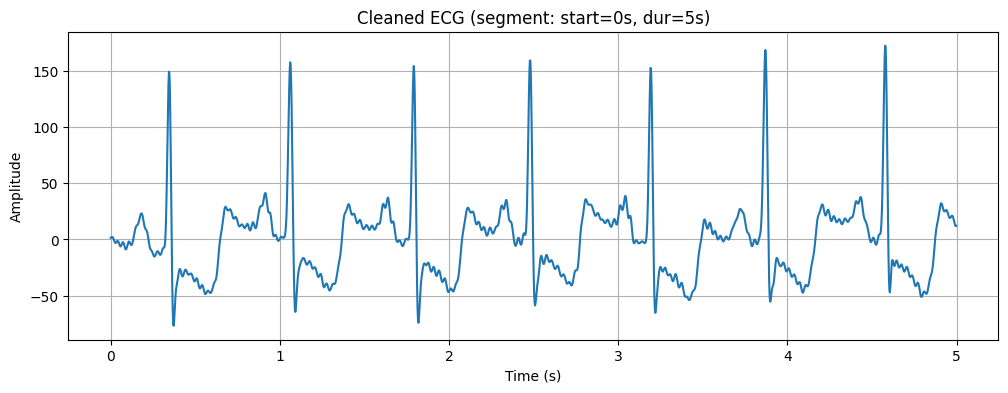

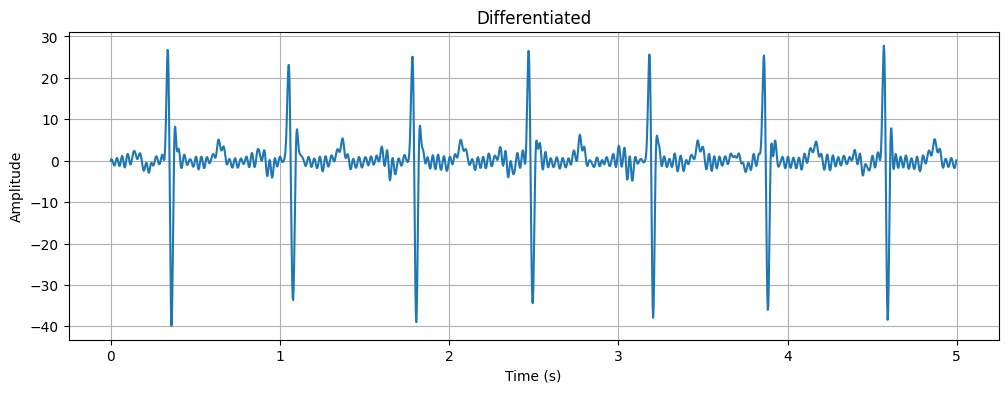

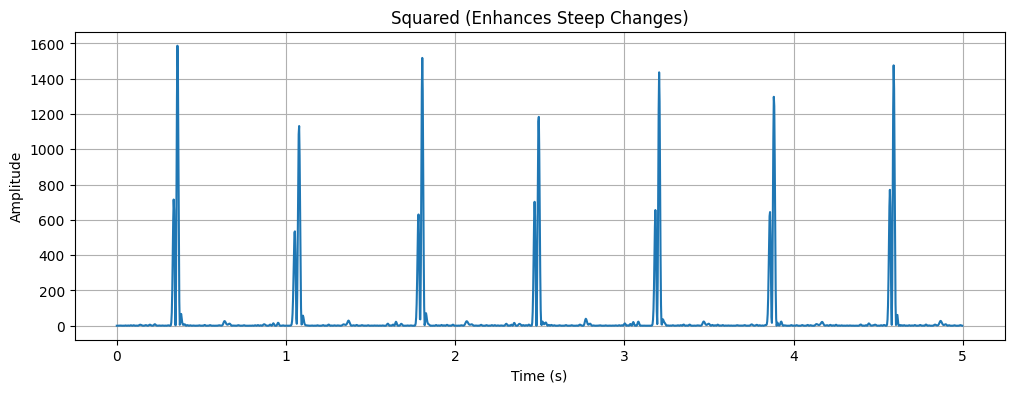

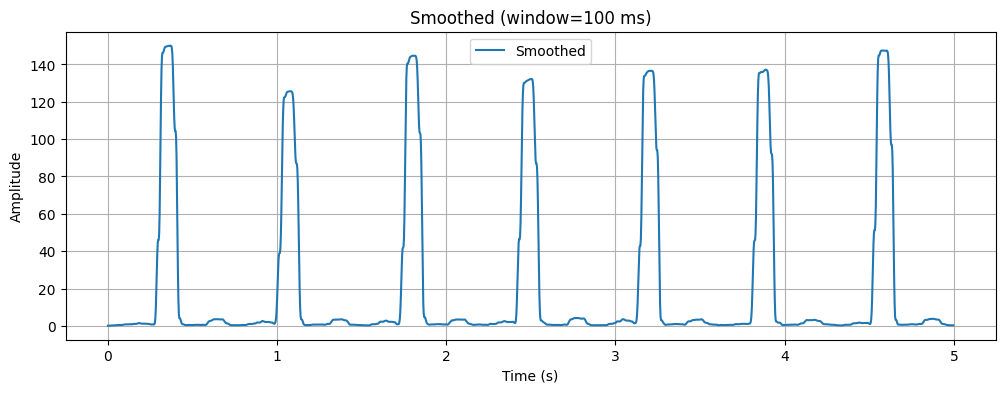

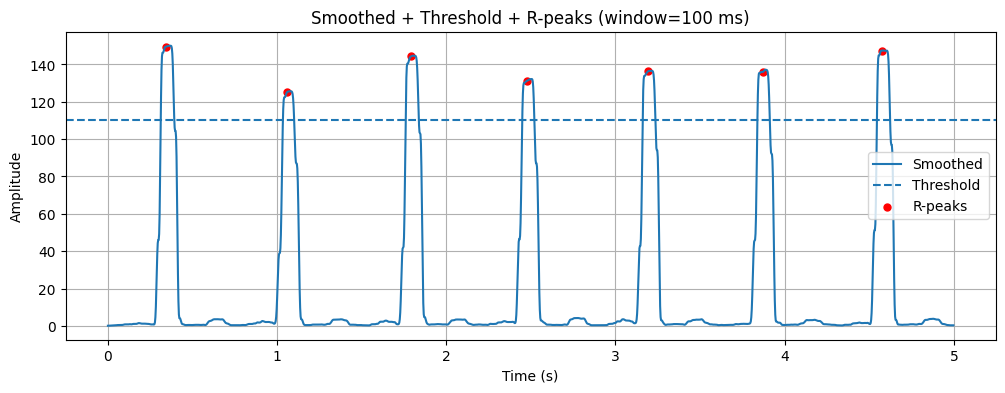

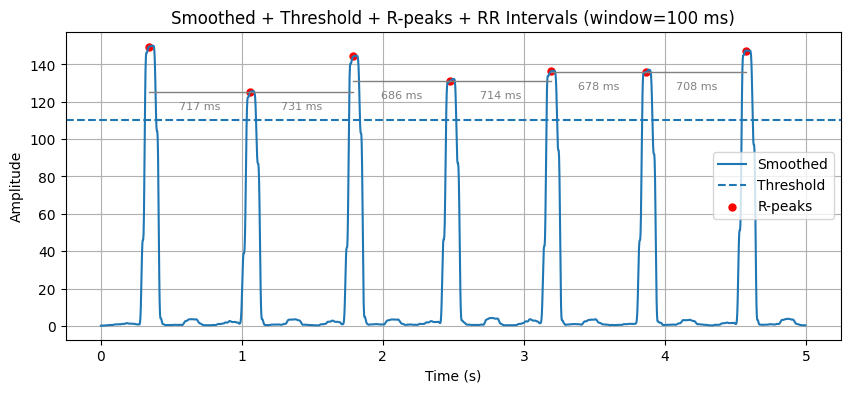

In [17]:
fs = 360 #sampling rate
results = plot_ecg_segment(ecg_cleaned, fs, start_sec=0, duration_sec=5, window_ms=100, thresh_k=2.5)

# Reference(s): 
[1][2]Task Force of the European Society of Cardiology and the North American Society of Pacing and Electrophysiology. Heart Rate Variability: Standards of Measurement, Physiological Interpretation, and Clinical Use. Circulation. 1996;93(5):1043-1065. https://www.escardio.org/static-file/Escardio/Guidelines/Scientific-Statements/guidelines-Heart-Rate-Variability-FT-1996.pdf

**Will be used for part 2 - Good Reference for HRV metics:** 
Pham T, Lau ZJ, Chen SHA, Makowski D. Heart Rate Variability in Psychology: A Review of HRV Indices and an Analysis Tutorial. Sensors. 2021; 21(12):3998. https://doi.org/10.3390/s21123998
